In [1]:
# Install library yang dibutuhkan
!pip install split-folders tensorflowjs -q

import os
from google.colab import files

# Mengunggah file kaggle.json
print("Silakan unggah file kaggle.json Anda:")
files.upload()

# Setup direktori Kaggle dan memindahkan file kredensial
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Mengunduh dataset GTSRB dari Kaggle
print("Mengunduh dataset...")
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

# Ekstrak dataset (kita abaikan output agar rapi)
!unzip -q gtsrb-german-traffic-sign.zip -d gtsrb_dataset
print("Dataset berhasil diunduh dan diekstrak!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 

Saving kaggle.json to kaggle.json
Mengunduh dataset...
Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:10<00:00, 60.4MB/s]

Dataset berhasil diunduh dan diekstrak!


In [2]:
import splitfolders

# Dataset GTSRB dari Kaggle memiliki folder 'Train' yang berisi 43 sub-folder kelas
base_dir = 'gtsrb_dataset/Train'
output_dir = 'dataset_split'

# Membagi dataset menjadi Train (80%), Val (10%), Test (10%)
splitfolders.ratio(base_dir, output=output_dir, seed=42, ratio=(0.8, 0.1, 0.1))

train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')

print("Pembagian dataset berhasil! Train, Validation, dan Test set telah dibuat.")

Copying files: 39209 files [00:11, 3468.64 files/s]

Pembagian dataset berhasil! Train, Validation, dan Test set telah dibuat.


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentasi hanya untuk data training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    shear_range=0.15,
    fill_mode="nearest"
)

# Hanya rescale untuk validation dan test set (tanpa augmentasi)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

target_size = (64, 64)
batch_size = 64

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=target_size, batch_size=batch_size, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=target_size, batch_size=batch_size, class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=target_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

Found 31367 images belonging to 43 classes.
Found 3920 images belonging to 43 classes.
Found 3922 images belonging to 43 classes.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # Layer Konvolusi 1
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Layer Konvolusi 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Layer Konvolusi 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5), # Mencegah overfitting
    Dense(43, activation='softmax') # 43 kelas rambu lalu lintas
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,476,011 (9.45 MB)

 Trainable params: 2,475,563 (9.44 MB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
# Callback untuk menghentikan training otomatis jika akurasi > 95%
class TargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('accuracy') >= 0.95 and logs.get('val_accuracy') >= 0.95:
            print("\nTarget akurasi Training & Validation > 95% telah tercapai, menghentikan training!")
            self.model.stop_training = True

callbacks = TargetCallback()

# Mulai training (epochs diset ke 30, tetapi akan berhenti otomatis jika callback aktif)
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[callbacks]
)

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 377s 758ms/step - accuracy: 0.7254 - loss: 1.0004 - val_accuracy: 0.9378 - val_loss: 0.2157
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 359s 730ms/step - accuracy: 0.9411 - loss: 0.1911 - val_accuracy: 0.9842 - val_loss: 0.0531
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.9657 - loss: 0.1142
Target akurasi Training & Validation > 95% telah tercapai, menghentikan training!
491/491 ━━━━━━━━━━━━━━━━━━━━ 356s 726ms/step - accuracy: 0.9642 - loss: 0.1197 - val_accuracy: 0.9622 - val_loss: 0.1373


In [6]:
# Menguji performa model dengan Test Set (data yang belum pernah dilihat sama sekali)
print("Mengevaluasi model pada Test Set...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Mengevaluasi model pada Test Set...
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.9671 - loss: 0.1148
Test Accuracy: 96.71%


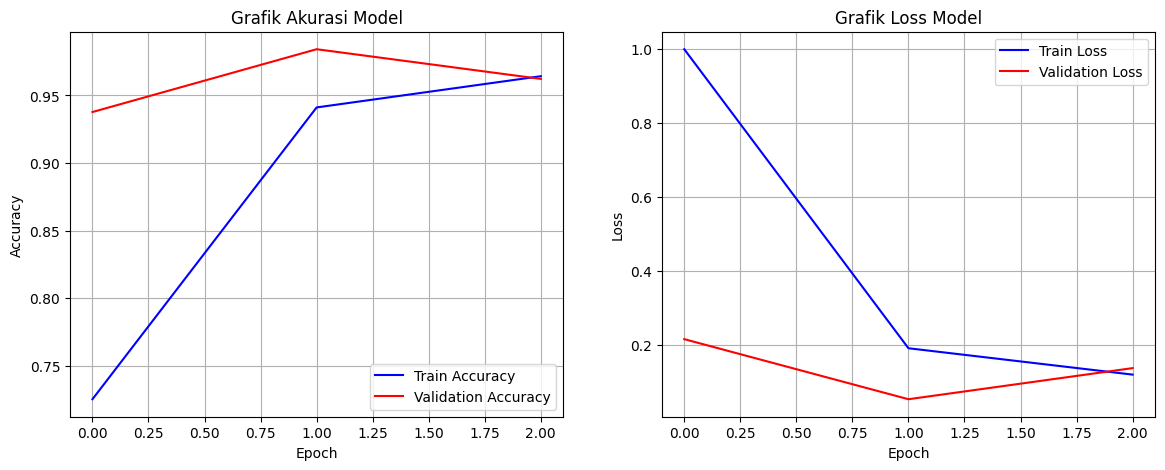

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Grafik Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Grafik Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

In [10]:
import tensorflowjs as tfjs
import pathlib

# 1. Format SavedModel
export_dir = 'saved_model_gtsrb/'
model.export(export_dir) # Changed to model.export for SavedModel format
print("Model berhasil disimpan dalam format SavedModel.")

# 2. Format TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()
tflite_model_file = pathlib.Path('model.tflite')
tflite_model_file.write_bytes(tflite_model)
print("Model berhasil dikonversi ke format TF-Lite.")

# 3. Format TFJS
tfjs.converters.save_keras_model(model, 'tfjs_model')
print("Model berhasil dikonversi ke format TFJS.")

Saved artifact at 'saved_model_gtsrb/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  139917740743312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139917740743504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139917740747728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139917740743120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139917740742928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139917740746768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139917740747920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139917740748304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139917740749456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139917740749648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1399177407475

Model berhasil dikonversi ke format TF-Lite.
failed to lookup keras version from the file,
    this is likely a weight only file
Model berhasil dikonversi ke format TFJS.


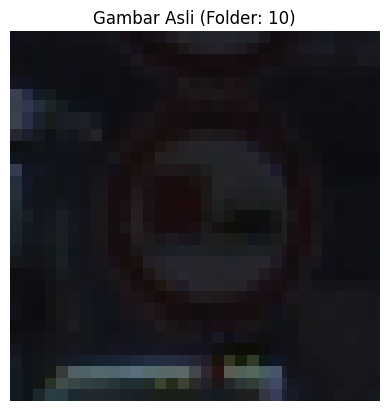


--- HASIL INFERENSI TF-LITE ---
Kelas Asli       : 10
Prediksi Model   : 10
Tingkat Keyakinan: 100.00%


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [11]:
import numpy as np
import random
from tensorflow.keras.preprocessing import image

# Ambil kelas dan satu gambar acak dari test set
class_names = list(train_generator.class_indices.keys())
random_class = random.choice(class_names)
random_image_file = random.choice(os.listdir(os.path.join(test_dir, random_class)))
img_path = os.path.join(test_dir, random_class, random_image_file)

# Tampilkan gambar
img = image.load_img(img_path, target_size=(64, 64))
plt.imshow(img)
plt.title(f"Gambar Asli (Folder: {random_class})")
plt.axis('off')
plt.show()

# Preprocessing gambar untuk model
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = x / 255.0  # Normalisasi yang sama dengan datagen

# Load TFLite model dan jalankan inferensi
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Masukkan gambar ke tensor input
interpreter.set_tensor(input_details[0]['index'], x)
interpreter.invoke()

# Ambil hasil dari tensor output
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_class_idx = np.argmax(output_data)
predicted_class = class_names[predicted_class_idx]
confidence = np.max(output_data) * 100

print(f"\n--- HASIL INFERENSI TF-LITE ---")
print(f"Kelas Asli       : {random_class}")
print(f"Prediksi Model   : {predicted_class}")
print(f"Tingkat Keyakinan: {confidence:.2f}%")

In [12]:
import os

# 1. Membuat struktur folder sesuai instruksi
!mkdir -p submission/tfjs_model
!mkdir -p submission/tflite
!mkdir -p submission/saved_model

# 2. Memasukkan model TFJS
!cp -r tfjs_model/* submission/tfjs_model/

# 3. Memasukkan model TFLite
!cp model.tflite submission/tflite/
# Membuat file label.txt untuk TFLite (Berisi nama kelas 0-42)
with open('submission/tflite/label.txt', 'w') as f:
    for i in range(43):
        f.write(f"{i}\n")

# 4. Memasukkan SavedModel (sekaligus me-rename foldernya)
!cp -r saved_model_gtsrb/* submission/saved_model/

# 5. Membuat file requirements.txt secara otomatis
!pip freeze > submission/requirements.txt

# 6. Membuat file README.md sederhana
!echo "# Submission Klasifikasi Gambar GTSRB" > submission/README.md

# 7. Membungkus semuanya menjadi file ZIP
!zip -r submission_siap_kumpul.zip submission/

print("\nBerhasil! Silakan refresh panel file di kiri, lalu download 'submission_siap_kumpul.zip'")

  adding: submission/ (stored 0%)
  adding: submission/README.md (stored 0%)
  adding: submission/tflite/ (stored 0%)
  adding: submission/tflite/model.tflite (deflated 7%)
  adding: submission/tflite/label.txt (deflated 44%)
  adding: submission/tfjs_model/ (stored 0%)
  adding: submission/tfjs_model/group1-shard1of3.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard3of3.bin (deflated 7%)
  adding: submission/tfjs_model/model.json (deflated 88%)
  adding: submission/tfjs_model/group1-shard2of3.bin (deflated 7%)
  adding: submission/requirements.txt (deflated 57%)
  adding: submission/saved_model/ (stored 0%)
  adding: submission/saved_model/variables/ (stored 0%)
  adding: submission/saved_model/variables/variables.index (deflated 69%)
  adding: submission/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: submission/saved_model/assets/ (stored 0%)
  adding: submission/saved_model/fingerprint.pb (stored 0%)
  adding: submission/saved_model/saved_mo